In [220]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

we will now build a more sophisticated model : MLP 
and get more context than just the previous character

there is C as activation layer /
hidden layer /
output layer 

In [25]:
# open list of name 

words = open('names.txt','r').read().splitlines()
words [:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [26]:
# create list for input and output 

chars = sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [147]:
# built the data set : we want 3 characters in the context window

Block_size = 3 # context window
X,Y = [],[]

for w in words:
    #print(w)
    context = [0] * Block_size

    for ch in w +'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i]for i in context), '--->', itos[ix])
        context=context[1:]+[ix]                                        #crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

### working lines

In [145]:
X.shape, Y.shape, X.dtype, Y.dtype

(torch.Size([32, 3]), torch.Size([32]), torch.int64, torch.int64)

In [85]:
# embedding Matrix

C = torch.randn(27,2)               #27 character in 2 dimensions
emb = C[X]                          #embedding our input X to C 
emb.shape                           # shape [number of input, context window, dimension]

torch.Size([32, 3, 2])

In [86]:
# but we dont want stacked tensor, we need same dimension for the @product 

emb = torch.cat(torch.unbind(emb,1),1)       #we concatenate all 3 [32,2] on the dimension[1] 

In [87]:
emb.shape

torch.Size([32, 6])

In [88]:
#hidden layer 

W1 = torch.randn(6,100)
B1 = torch.randn(100)

In [93]:
H = torch.tanh(emb @ W1 + B1)
H

tensor([[-0.5154,  0.9998,  0.8317,  ..., -0.6144, -0.4949, -0.9975],
        [ 0.3121,  0.9979,  0.9505,  ...,  0.2439, -0.7926,  0.0534],
        [ 0.8328,  0.9992,  0.9993,  ...,  0.9991,  0.4863,  0.7216],
        ...,
        [-0.9194, -0.6064, -0.9998,  ..., -0.9910,  0.0474,  0.0130],
        [ 0.7871,  0.3857,  0.9259,  ..., -0.6358,  0.9259, -0.1835],
        [-0.9855,  0.9999,  0.1080,  ...,  0.6564, -0.6217, -0.7702]])

In [94]:
H.shape

torch.Size([32, 100])

In [98]:
W2 = torch.randn(100,27)
B2 = torch.randn(27)


In [102]:
logits = H @ W2 + B2
counts = logits.exp()
probs=counts/counts.sum(1,keepdim=True)
probs

tensor([[4.0266e-04, 1.6611e-08, 3.5921e-07, 3.6999e-08, 1.7617e-04, 3.5369e-05,
         5.1979e-11, 8.5019e-01, 2.0191e-10, 4.7893e-07, 3.0346e-02, 7.7927e-06,
         2.5279e-03, 7.4684e-08, 1.0726e-04, 2.3437e-09, 3.6946e-02, 3.1027e-02,
         2.3620e-02, 4.4583e-06, 2.4821e-08, 3.1121e-08, 6.4203e-08, 2.4610e-02,
         2.6038e-09, 2.3679e-10, 2.5494e-11],
        [1.9731e-01, 1.9850e-04, 3.7089e-11, 1.4782e-06, 6.2320e-10, 5.9248e-04,
         4.4227e-11, 2.7787e-04, 2.9130e-08, 6.8956e-11, 7.0518e-06, 7.4434e-06,
         2.5070e-13, 1.9422e-11, 3.1832e-07, 6.4141e-10, 8.0097e-01, 2.8950e-04,
         3.4147e-04, 1.4171e-09, 8.6750e-11, 1.0112e-09, 1.3240e-08, 2.2230e-06,
         3.6601e-08, 1.5617e-12, 1.0351e-07],
        [1.5454e-05, 4.2191e-02, 8.6376e-13, 1.9380e-11, 6.4314e-07, 2.9706e-03,
         1.2734e-12, 1.5573e-06, 4.1542e-07, 5.0575e-07, 5.8128e-06, 6.6682e-10,
         7.9051e-05, 2.4794e-13, 4.5775e-05, 6.8880e-09, 4.6805e-04, 3.3794e-08,
         2.5223e-

### rearanging 

In [148]:
#data Set
X.shape, Y.shape, X.dtype, Y.dtype

(torch.Size([228146, 3]), torch.Size([228146]), torch.int64, torch.int64)

In [ ]:
# Parameters:

C=torch.randn(27,2)
W1=torch.randn(6,100)
B1=torch.randn(100)
W2=torch.randn(100,27)
B2=torch.randn(27)
parameters=[C, W1, B1, W2, B2]

for p in parameters:
    p.requires_grad = True

In [163]:
sum(p.nelement() for p in parameters)

3481

In [ ]:
for _ in range(100):

    # Forward pass
    emb = C[X]
    Emb=torch.cat(torch.unbind(emb,1),1) 
    H = torch.tanh(Emb @ W1 +B1)
    Logits = H @ W2 + B2

    #Proba & Loss ---> Interestingly this is exactly what the cross Enthropy function is doing 

    '''
    counts = Logits.exp()
    #probs = counts / counts.sum(1, keepdim=True)
    #loss = -probs[torch.arange(32),Y].log().mean()
    '''

    loss = F.cross_entropy(Logits,Y)
    print(loss.item())

    #backwardpass

    for p in parameters:
        p.grad = None
    loss.backward()

    #Update 

    for p in parameters:
        p.data += -0.1 * p.grad 


9.198836326599121
8.882163047790527
8.509075164794922
8.224442481994629
7.902388095855713
7.65025520324707
7.371947765350342
7.148139953613281
6.9085373878479
6.709354877471924
6.505041122436523
6.328396797180176
6.153875350952148
5.997812271118164
5.847464561462402
5.710202217102051
5.579901695251465
5.4597320556640625
5.346523761749268
5.241695880889893
5.143106460571289
5.051542282104492
4.965181350708008
4.884625434875488
4.808222770690918
4.7365803718566895
4.668223857879639
4.6038289070129395
4.542088031768799
4.483739376068115
4.427609920501709
4.374459266662598
4.3231964111328125
4.2746124267578125
4.227632522583008
4.183117866516113
4.13997745513916
4.099163055419922
4.059502601623535
4.022078037261963
3.9856038093566895
3.951324224472046
3.9177730083465576
3.8864123821258545
3.8555541038513184
3.826883316040039
3.7984659671783447
3.7722487449645996
3.74603533744812
3.722020149230957
3.697761058807373
3.675713062286377
3.653195381164551
3.632880449295044
3.61191725730896
3.593

### minibatch 

In reality this is not the most efficient, it is often too long to compute the exact gradient on the entire training set
we then prefer to train on minibatch --> makes the gradient less precise but makes the computation much faster and it is good enough 

In [202]:
for _ in range(100):

    # Minibatch Construct
    ix = torch.randint(0,X.shape[0],(32,))

    # Forward pass
    emb = C[X[ix]]
    Emb=torch.cat(torch.unbind(emb,1),1)                # to concatenate the different dimension 
    H = torch.tanh(Emb @ W1 +B1)
    Logits = H @ W2 + B2

    #Proba & Loss ---> Interestingly this is exactly what the cross Enthropy function is doing 
    '''
    counts = Logits.exp()
    #probs = counts / counts.sum(1, keepdim=True)
    #loss = -probs[torch.arange(32),Y].log().mean()
    '''

    loss = F.cross_entropy(Logits,Y[ix])

    #backwardpass
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update 
    for p in parameters:
        p.data += -0.1 * p.grad 

print(loss.item())                                     # here the loss is only for the specific mini batch so we need to evaluate for the whole set

2.6471667289733887


In [204]:
emb = C[X[ix]]
Emb=torch.cat(torch.unbind(emb,1),1)                # to concatenate the different dimension 
H = torch.tanh(Emb @ W1 +B1)
Logits = H @ W2 + B2
loss1 = F.cross_entropy(Logits,Y[ix])
loss1.item()

2.317883014678955

### Learning Rate

now we want to make sure the learning rate is at the sweet spot, not too fast, not too slow 

In [239]:
# Parameters:

C=torch.randn(27,2)
W1=torch.randn(6,100)
B1=torch.randn(100)
W2=torch.randn(100,27)
B2=torch.randn(27)
parameters=[C, W1, B1, W2, B2]

for p in parameters:
    p.requires_grad = True

In [234]:
# create the learning rate range

lre = torch.linspace(-3,0,1000)             # creating LR from 0.001 to 1
lrs = 10 ** lre

In [240]:
lri=[]
lossi=[]

for i in range(100000):

    # Minibatch Construct
    ix = torch.randint(0,X.shape[0],(32,))

    # Forward pass
    emb = C[X[ix]]
    Emb=torch.cat(torch.unbind(emb,1),1)                # to concatenate the different dimension 
    H = torch.tanh(Emb @ W1 +B1)
    Logits = H @ W2 + B2

    #Proba & Loss ---> Interestingly this is exactly what the cross Enthropy function is doing 
    '''
    counts = Logits.exp()
    #probs = counts / counts.sum(1, keepdim=True)
    #loss = -probs[torch.arange(32),Y].log().mean()
    '''

    loss = F.cross_entropy(Logits,Y[ix])
    #print(loss.item())

    #backwardpass
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update 
    lr=0.1
    for p in parameters:
        p.data += -lr * p.grad 

    #track stat
    
    #lri.append(lr)
    #lossi.append(loss.item())

print(loss.item())                                   # here the loss is only for the specific mini batch so we need to evaluate for the whole set

2.8294930458068848


In [241]:
emb = C[X[ix]]
Emb=torch.cat(torch.unbind(emb,1),1)                # to concatenate the different dimension 
H = torch.tanh(Emb @ W1 +B1)
Logits = H @ W2 + B2
loss1 = F.cross_entropy(Logits,Y[ix])
loss1.item()

2.440931797027588

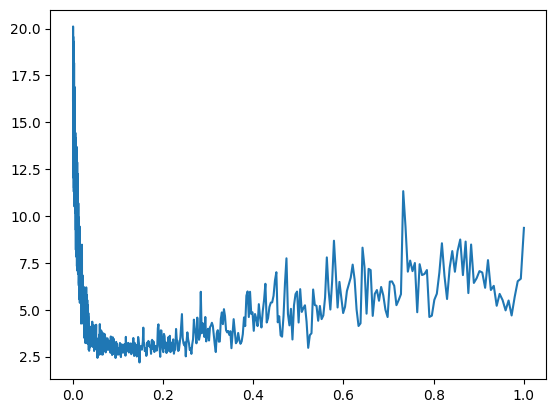

In [236]:
plt.plot(lri, lossi)

here we can see the best learning rate is around 0.1 --> now we have confidence we can keep this to train the model 

### Training and Test Set 

now we also dont want to overfit the model, so we need a training, dev, test set, with no data leakage

In [243]:
# built the data set : we want 3 characters in the context window

def build_dataset(words):
    Block_size = 3 # context window
    X,Y = [],[]

    for w in words:
        #print(w)
        context = [0] * Block_size

        for ch in w +'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]                                        #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


In [350]:
# Parameters:

C=torch.randn(27,10)
W1=torch.randn(30,200)
B1=torch.randn(200)
W2=torch.randn(200,27)
B2=torch.randn(27)
parameters=[C, W1, B1, W2, B2]

for p in parameters:
    p.requires_grad = True

Train on the training set

In [351]:
lri=[]
lossi=[]
stepi=[]

In [359]:


for i in range(50000):

    # Minibatch Construct
    ix = torch.randint(0,Xtr.shape[0],(32,))

    # Forward pass
    emb = C[Xtr[ix]]
    Emb=emb.view(-1,30)              # to concatenate the different dimension // here changing the function to .view() need to be mindful and adapt
    H = torch.tanh(Emb @ W1 +B1)
    Logits = H @ W2 + B2

    #Proba & Loss ---> Interestingly this is exactly what the cross Enthropy function is doing 
    '''
    counts = Logits.exp()
    #probs = counts / counts.sum(1, keepdim=True)
    #loss = -probs[torch.arange(32),Y].log().mean()
    '''

    loss = F.cross_entropy(Logits,Ytr[ix])
    #print(loss.item())

    #backwardpass
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update 
    lr=0.01
    for p in parameters:
        p.data += -lr * p.grad 

    #track stat
    
    #lri.append(lr)
    lossi.append(loss.log().item()) 
    stepi.append(i)

print(loss.item())                                   # here the loss is only for the specific mini batch so we need to evaluate for the whole set

2.4134230613708496


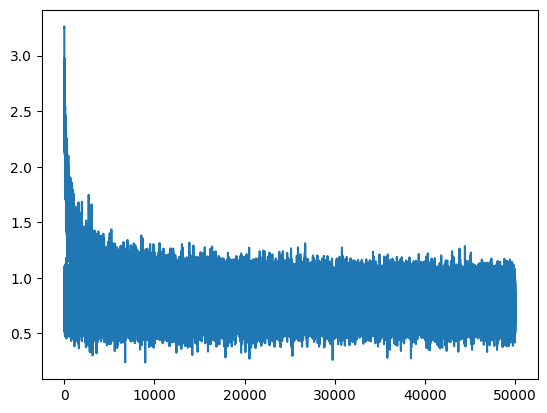

In [356]:
plt.plot(stepi,lossi)

Evaluation on the whole set, not just the minibatch 

In [360]:
emb = C[Xtr]
Emb=torch.cat(torch.unbind(emb,1),1)                # to concatenate the different dimension 
H = torch.tanh(Emb @ W1 +B1)
Logits = H @ W2 + B2
loss1 = F.cross_entropy(Logits,Ytr)
loss1.item()

2.0873372554779053

evaluation on the Dev Set

In [361]:
emb = C[Xdev]
Emb=torch.cat(torch.unbind(emb,1),1)                # to concatenate the different dimension 
H = torch.tanh(Emb @ W1 +B1)
Logits = H @ W2 + B2
loss1 = F.cross_entropy(Logits,Ydev)
loss1.item()

2.1459877490997314